# Multivariate analysis

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt

# Load data and strip whitespace from column names AND string values
reliability_df = pd.read_csv("../../data/cross_split_metrics.csv")
quality_df = pd.read_csv("../../data/image_quality_metrics.csv")
infodump_df = pd.read_csv("../../data/raw_subject_data.csv")
subjects_df = pd.read_csv("../../data/subject.csv")
split_comp_df = pd.read_csv("../../data/split_comparision_data.csv")

import _functions as mf

from _functions import (
    run_regression_model,
    plot_regression_results,
    compare_models,
    residualize,
)

## Vol_diff ~ GA + SNR_diff + QA_diff + stack_count


Data prepared:
  S1-S2: 23 subjects
  S3-S4: 23 subjects

Table: Regression of SP Volume Diff (S1-S2)
Variable       Coef     SE       t    p-value
-----------  ------  -----  ------  ---------
Intercept    -1.618  1.142  -1.420      0.174
GA            0.076  0.038   1.990      0.063
qa_diff      -1.411  1.326  -1.060      0.302
stack_count  -0.007  0.035  -0.190      0.852
snr_diff_sp   0.449  0.270   1.660      0.114
R-squared            0.284
Adj. R-squared       0.124
N                       23
F-statistic           1.78

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                  8.20 *
  qa_diff             2.72
  stack_count         6.38 *
  snr_diff_sp         2.71

Table: Regression of SP Volume Diff (S3-S4)
Variable       Coef     SE       t  p-value
-----------  ------  -----  ------  ---------
Intercept    -2.955  1.425  -2.070  0.053
GA            0.110  0.046   2.400  0.027 *
qa_diff       2.953  1.527   1.930  0.069
stack

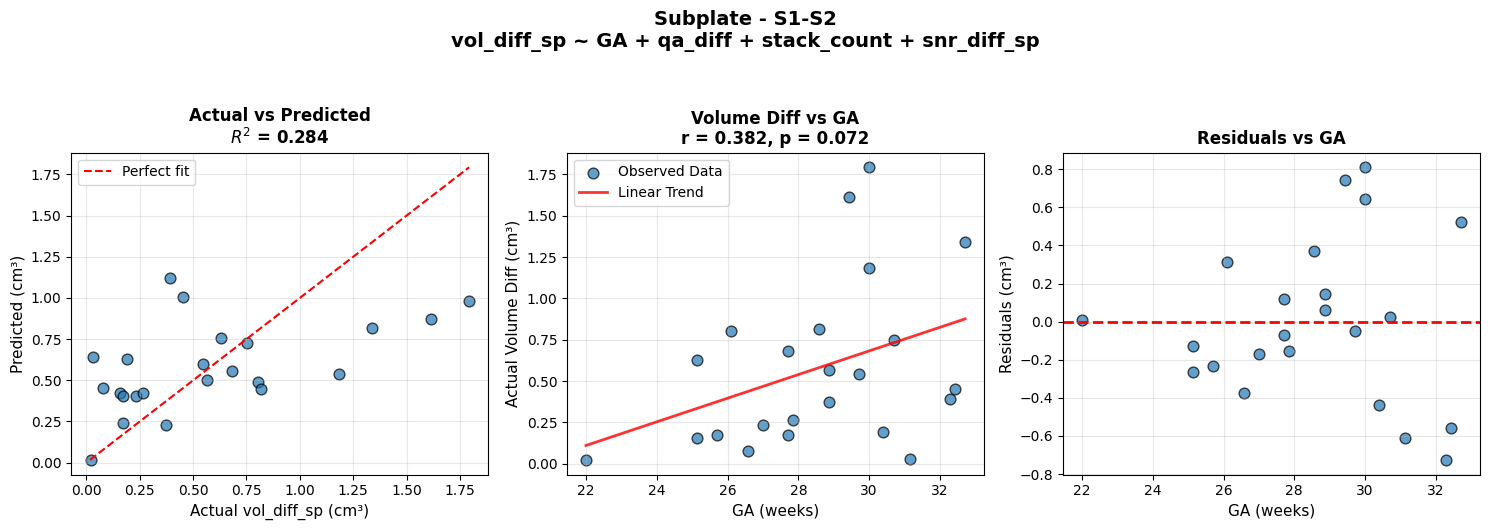

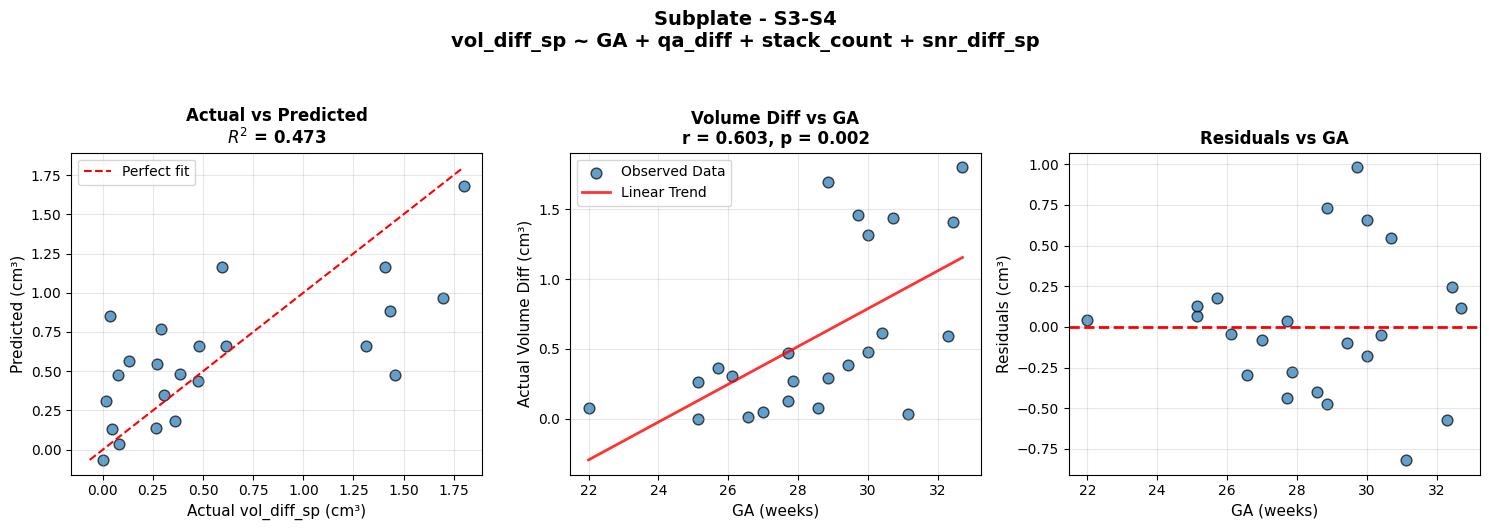

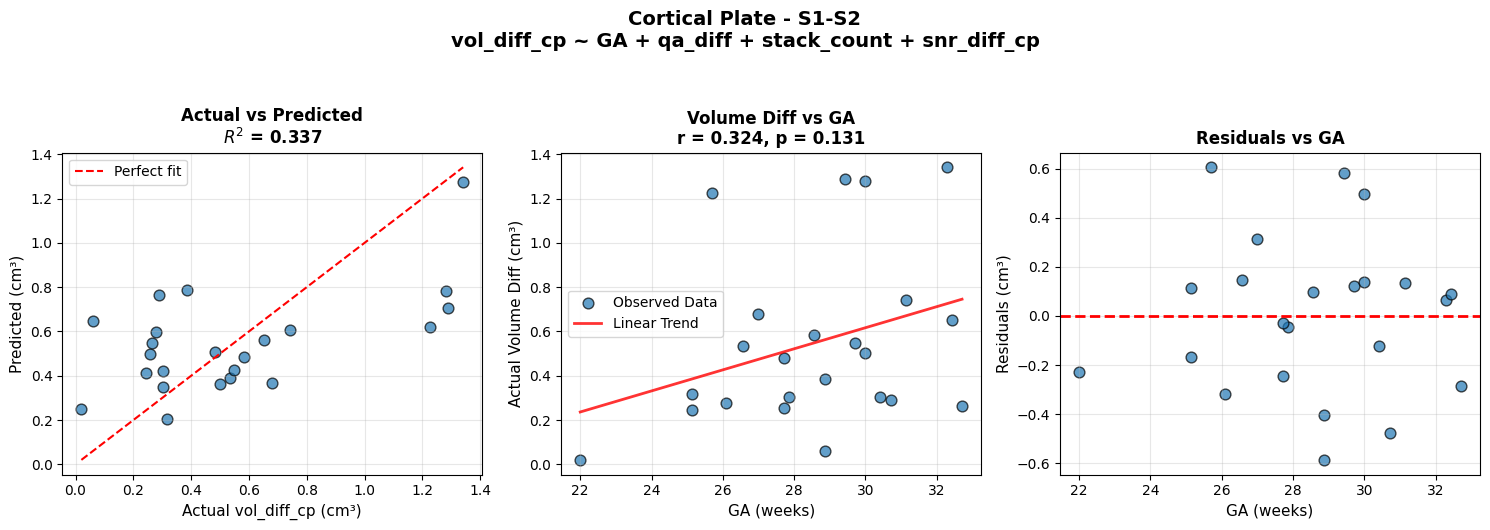

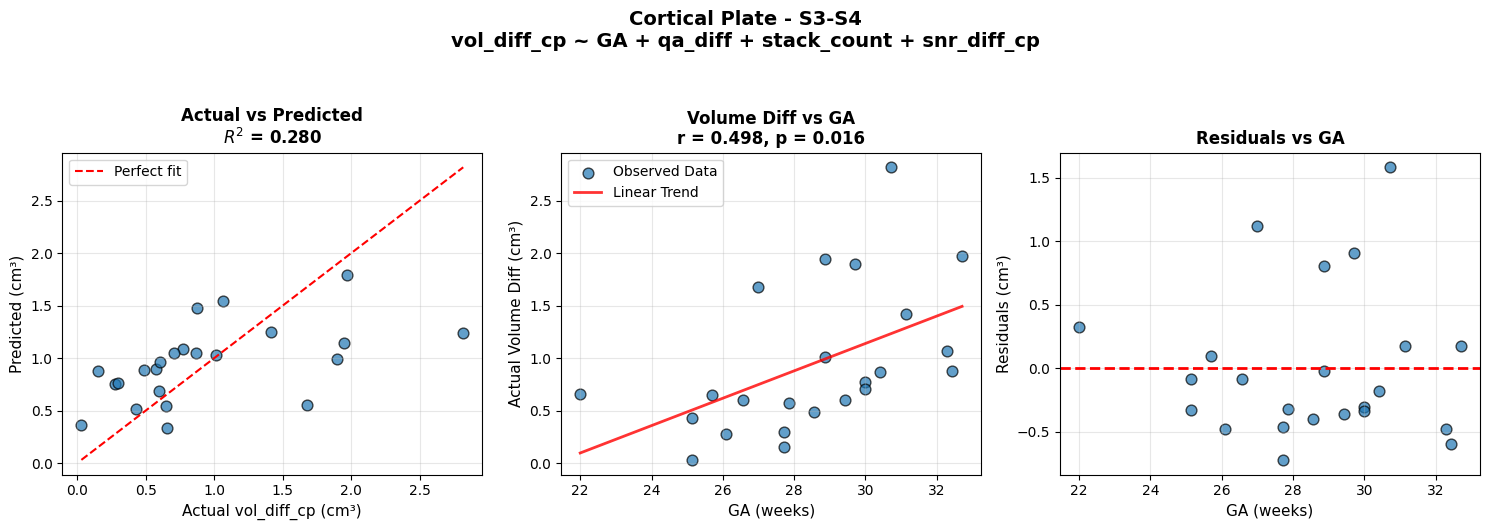

In [45]:

# Prepare data for each split pair
data_S1S2 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S1-S2")
data_S3S4 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S3-S4")

print("\nData prepared:")
print(f"  S1-S2: {len(data_S1S2)} subjects")
print(f"  S3-S4: {len(data_S3S4)} subjects")

# Define model predictors
predictors = ["GA", "qa_diff", "stack_count"]

# Run all 4 models using universal function
results = []
model_configs = [
    (data_S1S2, "vol_diff_sp", "snr_diff_sp", "sp", "S1-S2", "Subplate"),
    (data_S3S4, "vol_diff_sp", "snr_diff_sp", "sp", "S3-S4", "Subplate"),
    (data_S1S2, "vol_diff_cp", "snr_diff_cp", "cp", "S1-S2", "Cortical Plate"),
    (data_S3S4, "vol_diff_cp", "snr_diff_cp", "cp", "S3-S4", "Cortical Plate"),
]

for data, outcome_col, snr_col, tissue, split_pair, tissue_name in model_configs:
    # Add SNR difference to predictors for this model
    model_predictors = predictors + [snr_col]
    
    result = run_regression_model(
        df=data,
        outcome_col=outcome_col,
        predictors=model_predictors,
        model_name="Multivariate",
        split_pair=split_pair,
        tissue=tissue,
        print_results=True
    )
    results.append(result)

# Comparison table
compare_models(results)

# Generate plots
print(f"\n{'='*80}")
print("GENERATING VISUALIZATIONS")
print(f"{'='*80}")

for i, (data, outcome_col, snr_col, tissue, split_pair, tissue_name) in enumerate(model_configs):
    if results[i] is not None:
        fig = plot_regression_results(
            df=data, 
            outcome_col=outcome_col, 
            model_result=results[i],
            tissue_name=tissue_name,
            split_pair=split_pair
        )
        plt.show()


# ### Residualized Model Application: Vol_diff ~ GA + SNR_diff + QA_diff + stack_count_resid

RESIDUALIZED MODEL: Vol_diff ~ GA + SNR_diff + QA_diff + stack_count_resid
(stack_count_resid = stack_count with GA component removed)

--- Residualizing stack_count for S1-S2 ---
Residualizing: stack_count ~ GA
  Original correlation: r = -0.159, p = 0.4696
  Regression R² = 0.0252
  Slope = -0.1793 (p = 0.4696)
  Residuals capture 97.5% unique variance

--- Residualizing stack_count for S3-S4 ---
Residualizing: stack_count ~ GA
  Original correlation: r = -0.159, p = 0.4696
  Regression R² = 0.0252
  Slope = -0.1793 (p = 0.4696)
  Residuals capture 97.5% unique variance

Table: Regression of SP Volume Diff (S1-S2)
Variable             Coef     SE       t    p-value
-----------------  ------  -----  ------  ---------
Intercept          -1.697  1.078  -1.570      0.133
GA                  0.077  0.038   2.040      0.057
qa_diff            -1.411  1.326  -1.060      0.302
stack_count_resid  -0.007  0.035  -0.190      0.852
snr_diff_sp         0.449  0.270   1.660      0.114
R-squared   

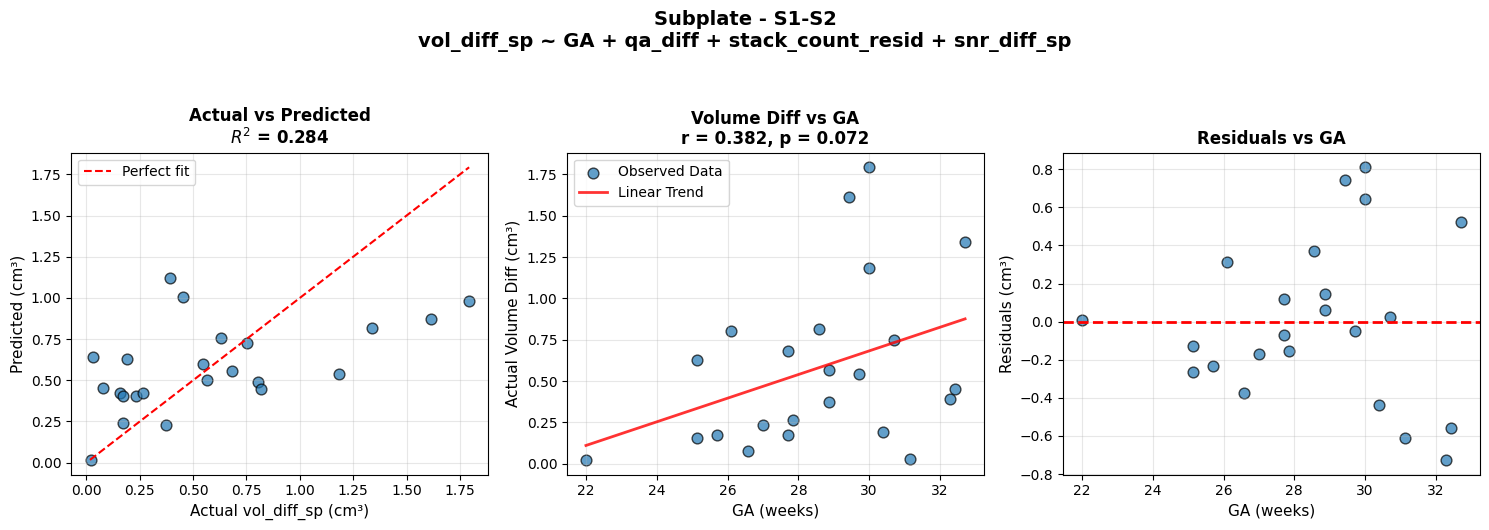

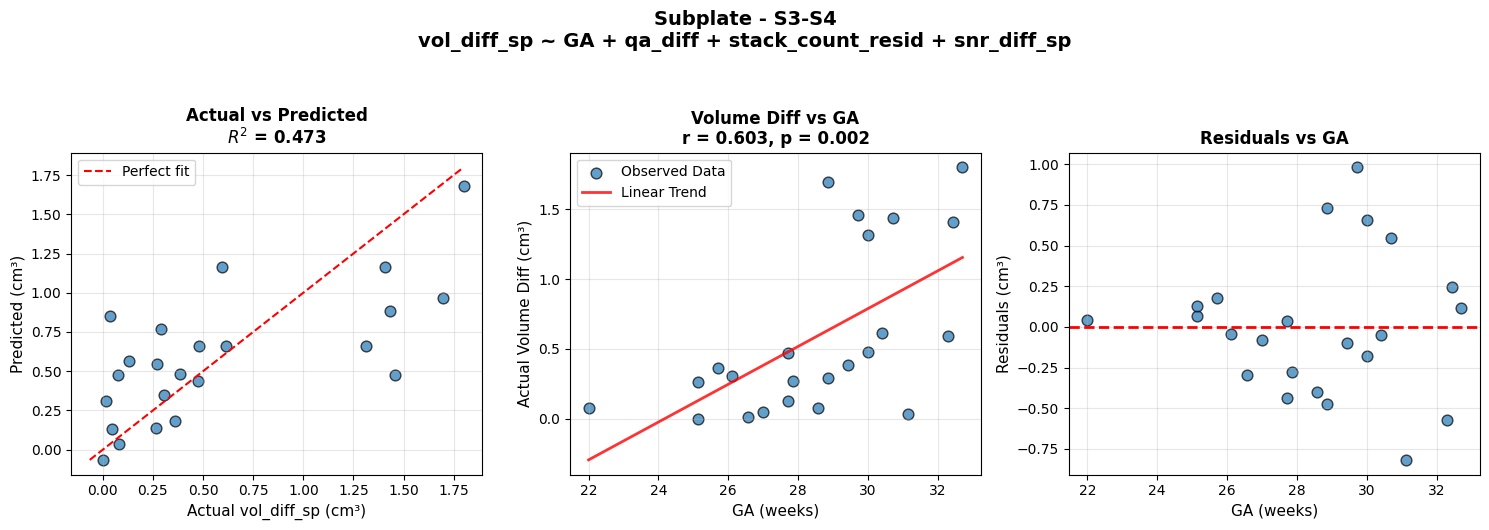

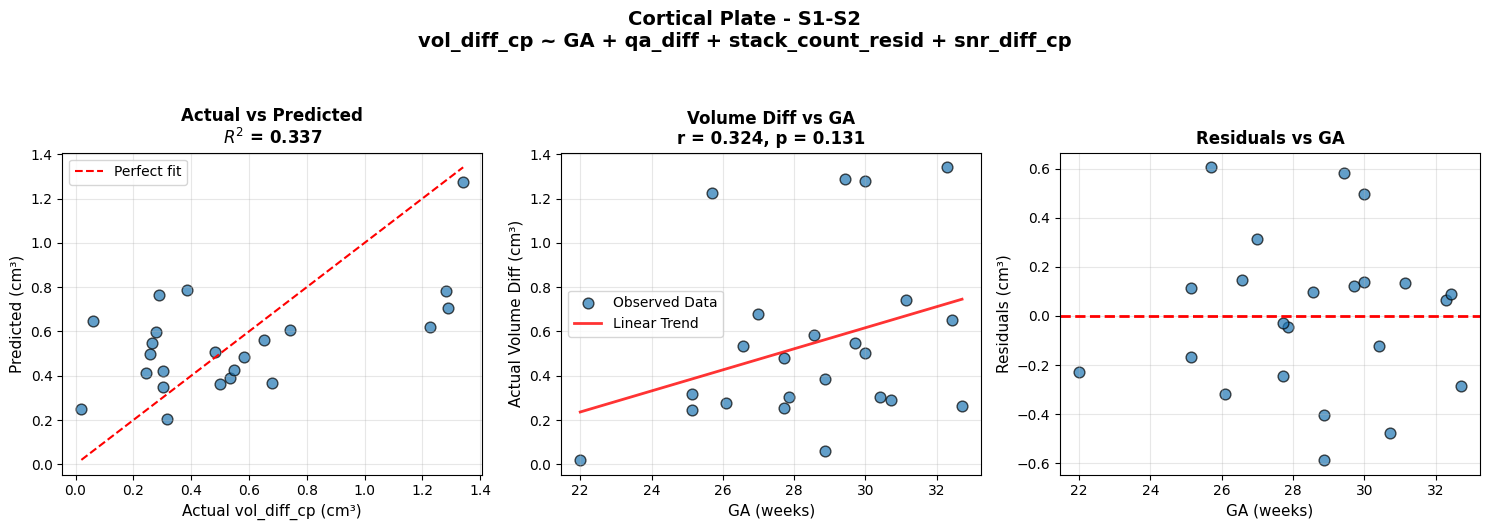

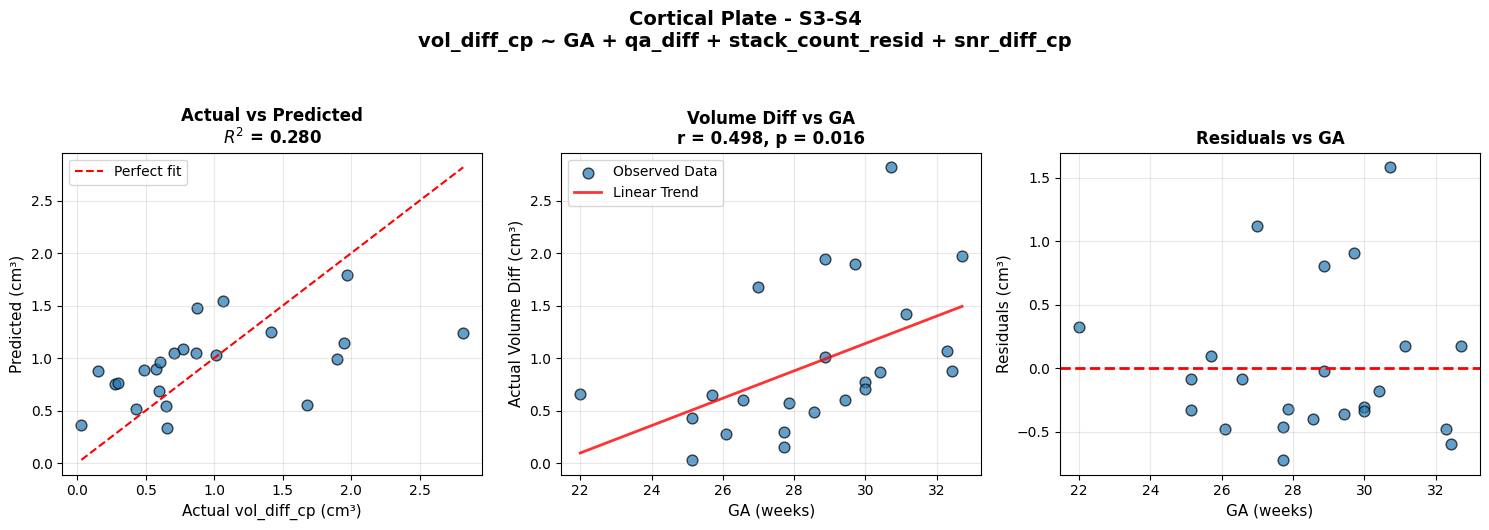

In [46]:


# =============================================================================
# RESIDUALIZED MODEL APPLICATION
# =============================================================================

print("=" * 80)
print("RESIDUALIZED MODEL: Vol_diff ~ GA + SNR_diff + QA_diff + stack_count_resid")
print("(stack_count_resid = stack_count with GA component removed)")
print("=" * 80)

# Prepare data with residualized stack_count
print("\n--- Residualizing stack_count for S1-S2 ---")
data_resid_S1S2 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S1-S2")
data_resid_S1S2["stack_count_resid"] = residualize(
    data_resid_S1S2, "stack_count", "GA", print_diagnostics=True
)

print("\n--- Residualizing stack_count for S3-S4 ---")
data_resid_S3S4 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S3-S4")
data_resid_S3S4["stack_count_resid"] = residualize(
    data_resid_S3S4, "stack_count", "GA", print_diagnostics=True
)

# Define residualized model predictors
resid_predictors = ["GA", "qa_diff", "stack_count_resid"]

# Run residualized models
results_resid = []
resid_configs = [
    (data_resid_S1S2, "vol_diff_sp", "snr_diff_sp", "sp", "S1-S2", "Subplate"),
    (data_resid_S3S4, "vol_diff_sp", "snr_diff_sp", "sp", "S3-S4", "Subplate"),
    (data_resid_S1S2, "vol_diff_cp", "snr_diff_cp", "cp", "S1-S2", "Cortical Plate"),
    (data_resid_S3S4, "vol_diff_cp", "snr_diff_cp", "cp", "S3-S4", "Cortical Plate"),
]

for data, outcome_col, snr_col, tissue, split_pair, tissue_name in resid_configs:
    # Add SNR difference to predictors for this model
    model_predictors = resid_predictors + [snr_col]
    
    result = run_regression_model(
        df=data,
        outcome_col=outcome_col,
        predictors=model_predictors,
        model_name="Residualized",
        split_pair=split_pair,
        tissue=tissue,
        print_results=True
    )
    results_resid.append(result)

# Comparison table
compare_models(results_resid)

# Generate plots
print(f"\n{'='*80}")
print("GENERATING RESIDUALIZED MODEL VISUALIZATIONS")
print(f"{'='*80}")

for i, (data, outcome_col, snr_col, tissue, split_pair, tissue_name) in enumerate(resid_configs):
    if results_resid[i] is not None:
        fig = plot_regression_results(
            df=data, 
            outcome_col=outcome_col, 
            model_result=results_resid[i],
            tissue_name=tissue_name,
            split_pair=split_pair
        )
        plt.show()


# ### QA-Mean Model Application: Vol_diff ~ GA + SNR_diff + QA_mean + stack_count

QA-MEAN MODEL: Vol_diff ~ GA + SNR_diff + QA_mean + stack_count
(Uses overall reconstruction quality instead of quality difference)

Data prepared:
  S1-S2: 23 subjects
  S3-S4: 23 subjects

Table: Regression of SP Volume Diff (S1-S2)
Variable       Coef     SE       t    p-value
-----------  ------  -----  ------  ---------
Intercept    -1.177  1.210  -0.970      0.343
GA            0.077  0.038   2.010      0.060
qa_mean      -0.736  0.694  -1.060      0.303
stack_count  -0.018  0.038  -0.480      0.640
snr_diff_sp   0.354  0.267   1.320      0.202
R-squared            0.283
Adj. R-squared       0.124
N                       23
F-statistic           1.78

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                 35.70 *
  qa_mean            21.13 *
  stack_count         6.98 *
  snr_diff_sp         2.65

Table: Regression of SP Volume Diff (S3-S4)
Variable       Coef     SE       t  p-value
-----------  ------  -----  ------  ---------

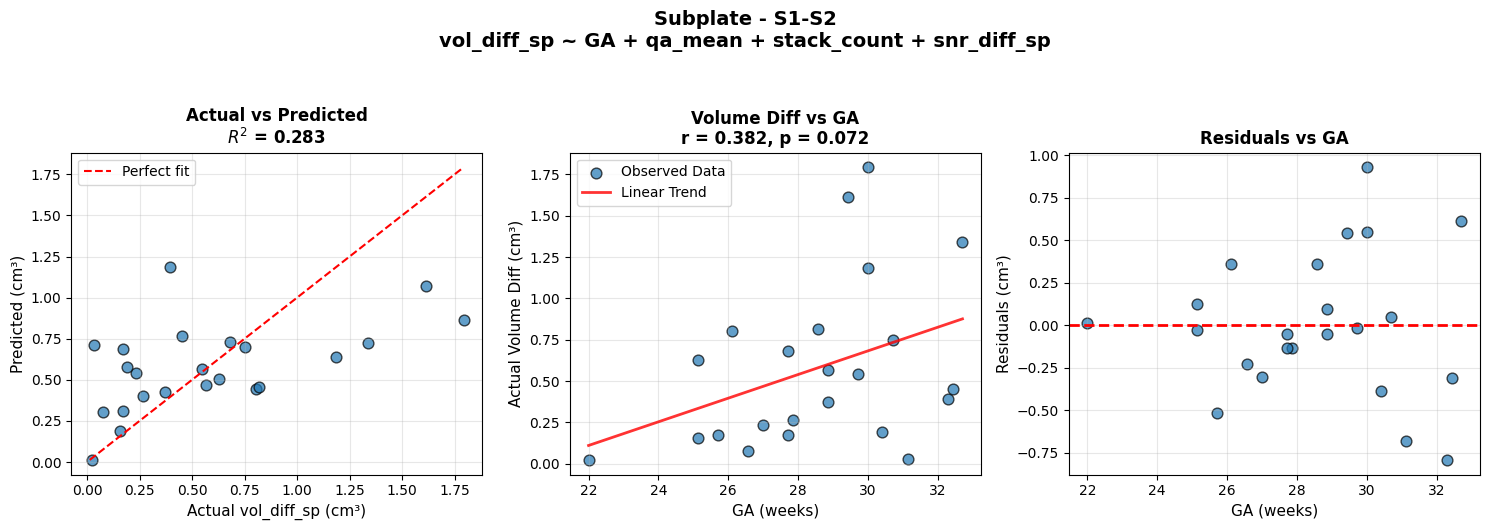

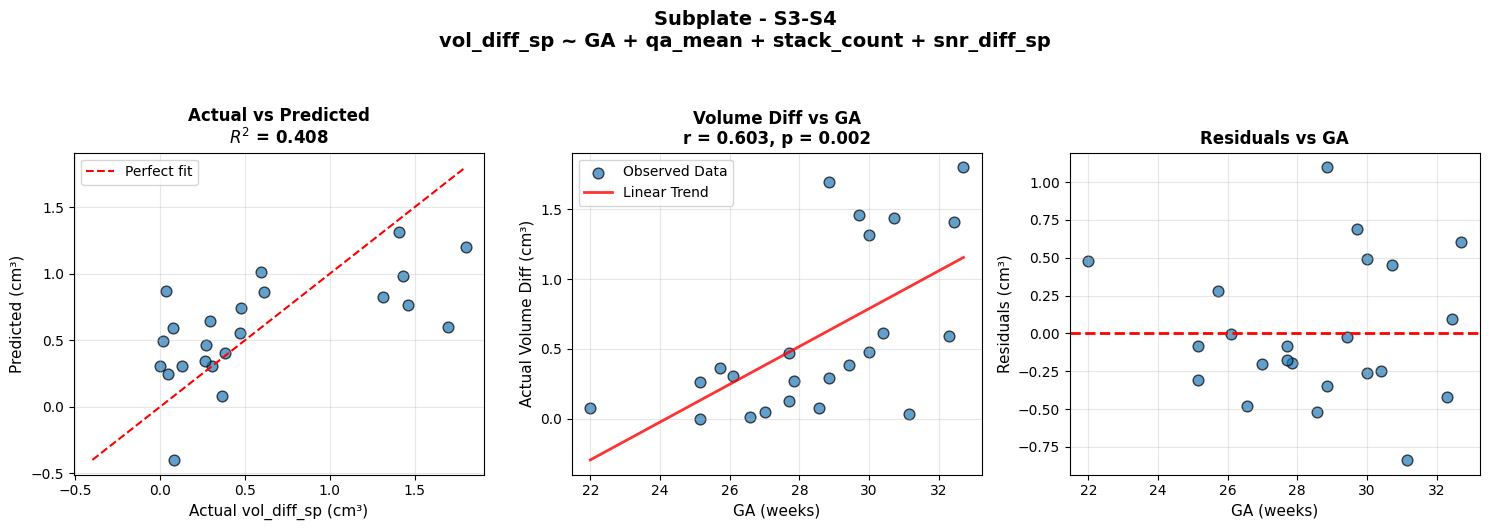

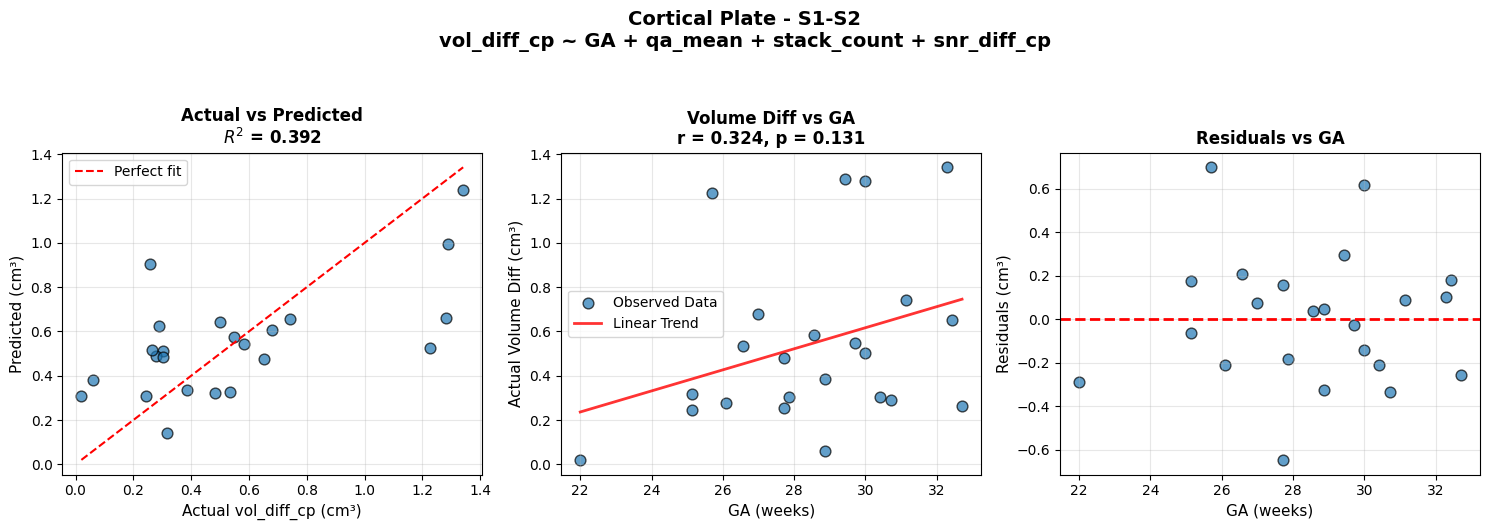

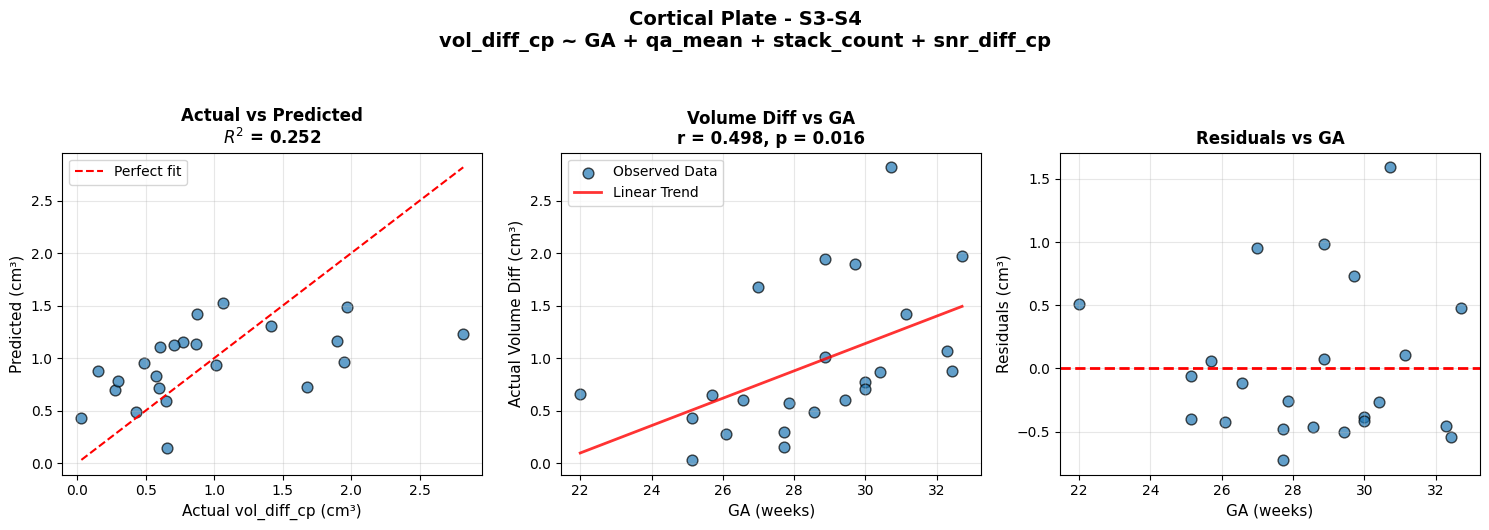

In [47]:


# =============================================================================
# QA-MEAN MODEL APPLICATION  
# =============================================================================

print("=" * 80)
print("QA-MEAN MODEL: Vol_diff ~ GA + SNR_diff + QA_mean + stack_count")
print("(Uses overall reconstruction quality instead of quality difference)")
print("=" * 80)

# Prepare data and add QA mean columns
data_qamean_S1S2 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S1-S2")
data_qamean_S3S4 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S3-S4")

# Add QA mean columns from infodump_df
for data, split_pair in [(data_qamean_S1S2, "S1-S2"), (data_qamean_S3S4, "S3-S4")]:
    qa_mean_col = "QA12_mean" if split_pair == "S1-S2" else "QA34_mean"
    # Merge QA mean data
    infodump_subset = infodump_df[["subject_id", "session_id", qa_mean_col]].copy()
    infodump_subset["subject_id"] = infodump_subset["subject_id"].astype(str)
    infodump_subset["session_id"] = infodump_subset["session_id"].astype(str)
    
    data_merged = data.merge(infodump_subset, on=["subject_id", "session_id"], how="left")
    data_merged["qa_mean"] = data_merged[qa_mean_col]
    
    # Update the original data
    if split_pair == "S1-S2":
        data_qamean_S1S2 = data_merged
    else:
        data_qamean_S3S4 = data_merged

print("\nData prepared:")
print(f"  S1-S2: {len(data_qamean_S1S2)} subjects")
print(f"  S3-S4: {len(data_qamean_S3S4)} subjects")

# Define QA-mean model predictors  
qa_mean_predictors = ["GA", "qa_mean", "stack_count"]

# Run QA-mean models using universal function
results_qamean = []
qamean_configs = [
    (data_qamean_S1S2, "vol_diff_sp", "snr_diff_sp", "sp", "S1-S2", "Subplate"),
    (data_qamean_S3S4, "vol_diff_sp", "snr_diff_sp", "sp", "S3-S4", "Subplate"),
    (data_qamean_S1S2, "vol_diff_cp", "snr_diff_cp", "cp", "S1-S2", "Cortical Plate"),
    (data_qamean_S3S4, "vol_diff_cp", "snr_diff_cp", "cp", "S3-S4", "Cortical Plate"),
]

for data, outcome_col, snr_col, tissue, split_pair, tissue_name in qamean_configs:
    # Add SNR difference to predictors for this model
    model_predictors = qa_mean_predictors + [snr_col]
    
    result = run_regression_model(
        df=data,
        outcome_col=outcome_col,
        predictors=model_predictors,
        model_name="QA-Mean", 
        split_pair=split_pair,
        tissue=tissue,
        print_results=True
    )
    results_qamean.append(result)

# Comparison table
compare_models(results_qamean)

# Generate plots
print(f"\n{'='*80}")
print("GENERATING QA-MEAN MODEL VISUALIZATIONS")
print(f"{'='*80}")

for i, (data, outcome_col, snr_col, tissue, split_pair, tissue_name) in enumerate(qamean_configs):
    if results_qamean[i] is not None:
        fig = plot_regression_results(
            df=data,
            outcome_col=outcome_col, 
            model_result=results_qamean[i],
            tissue_name=tissue_name,
            split_pair=split_pair
        )
        plt.show()



## Vol_diff ~ GA + CNR_diff/CNR_mean + QA_diff + stack_count

CNR-DIFF MODEL: Vol_diff ~ GA + CNR_diff + QA_diff + stack_count
(Uses CNR difference between splits - contrast-based quality metric)

Data prepared:
  S1-S2: 23 subjects
  S3-S4: 23 subjects

Table: Regression of SP Volume Diff (S1-S2)
Variable        Coef      SE       t    p-value
-----------  -------  ------  ------  ---------
Intercept     -1.776   1.199  -1.480      0.156
GA             0.075   0.040   1.880      0.077
cnr_diff     104.927  99.454   1.060      0.305
qa_diff       -0.762   1.370  -0.560      0.585
stack_count    0.017   0.036   0.470      0.643
R-squared            0.222
Adj. R-squared       0.049
N                       23
F-statistic           1.28

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                 12.51 *
  cnr_diff            3.46
  qa_diff             2.68
  stack_count         5.98 *

Table: Regression of SP Volume Diff (S3-S4)
Variable        Coef      SE       t  p-value
-----------  -------  ------ 

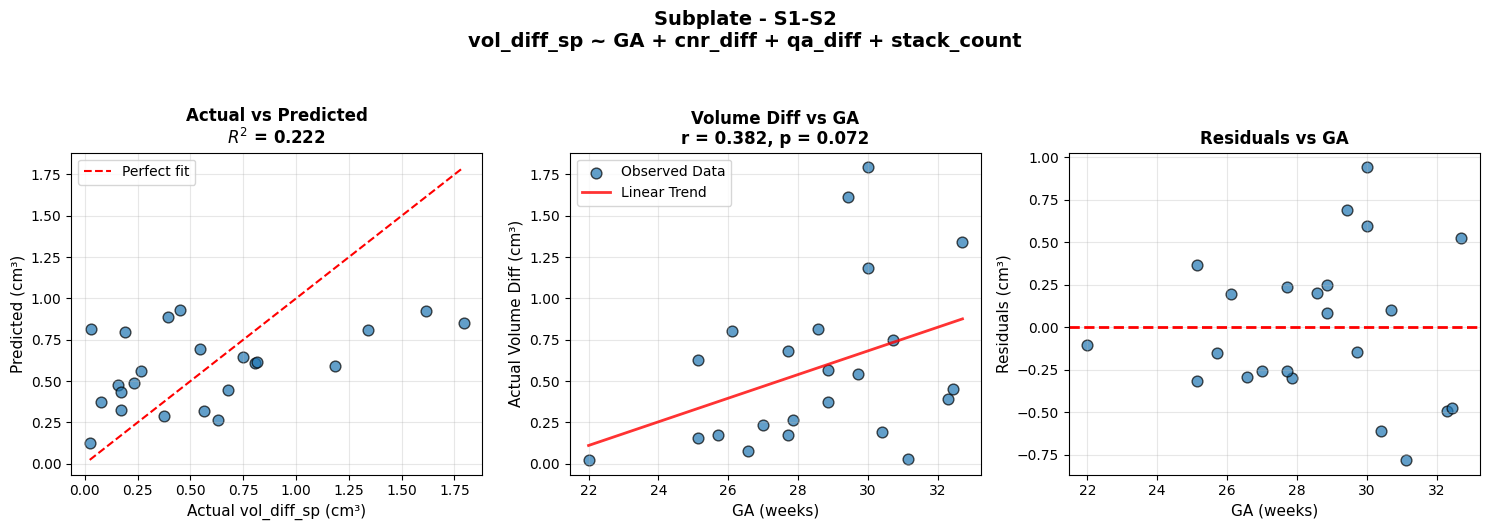

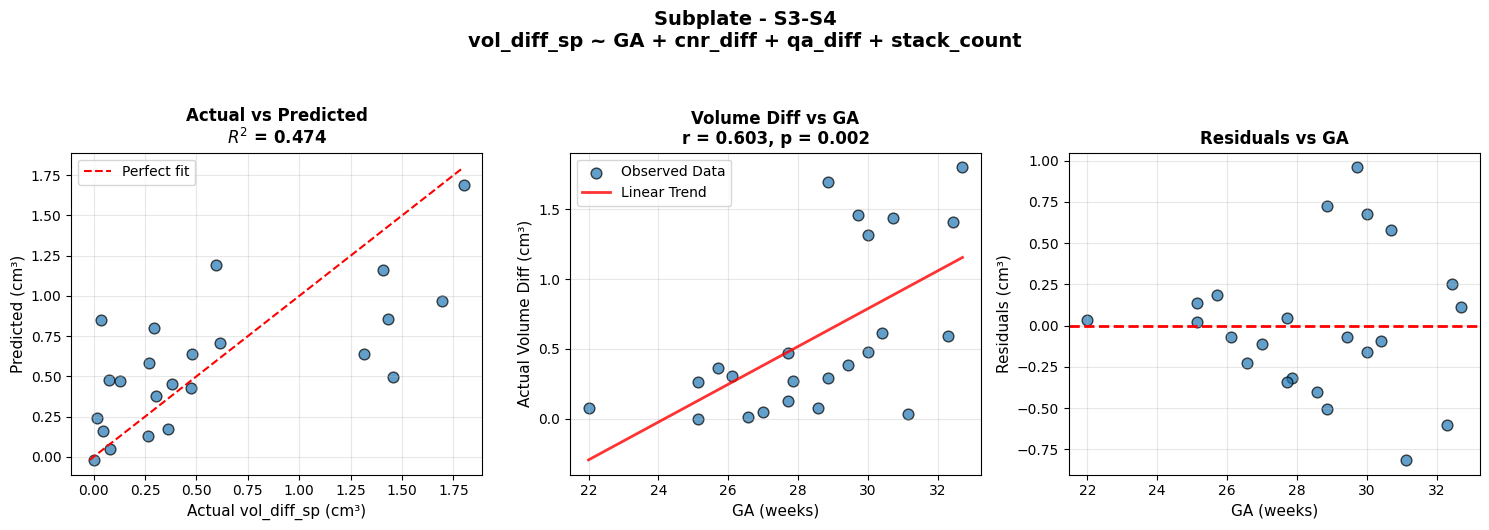

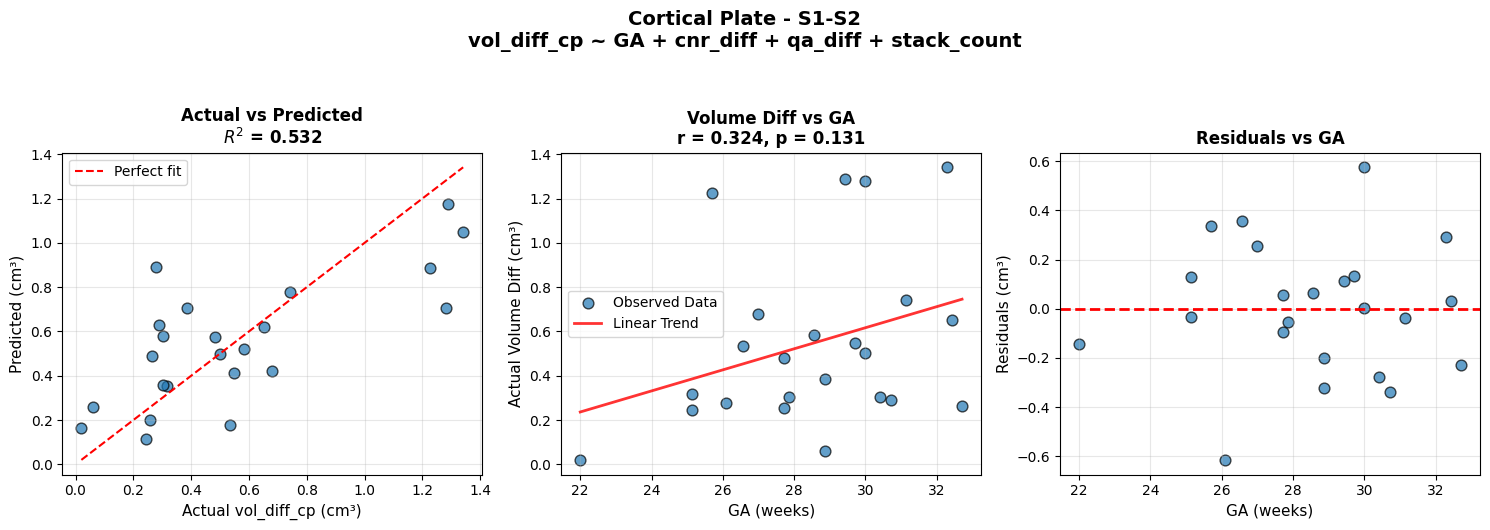

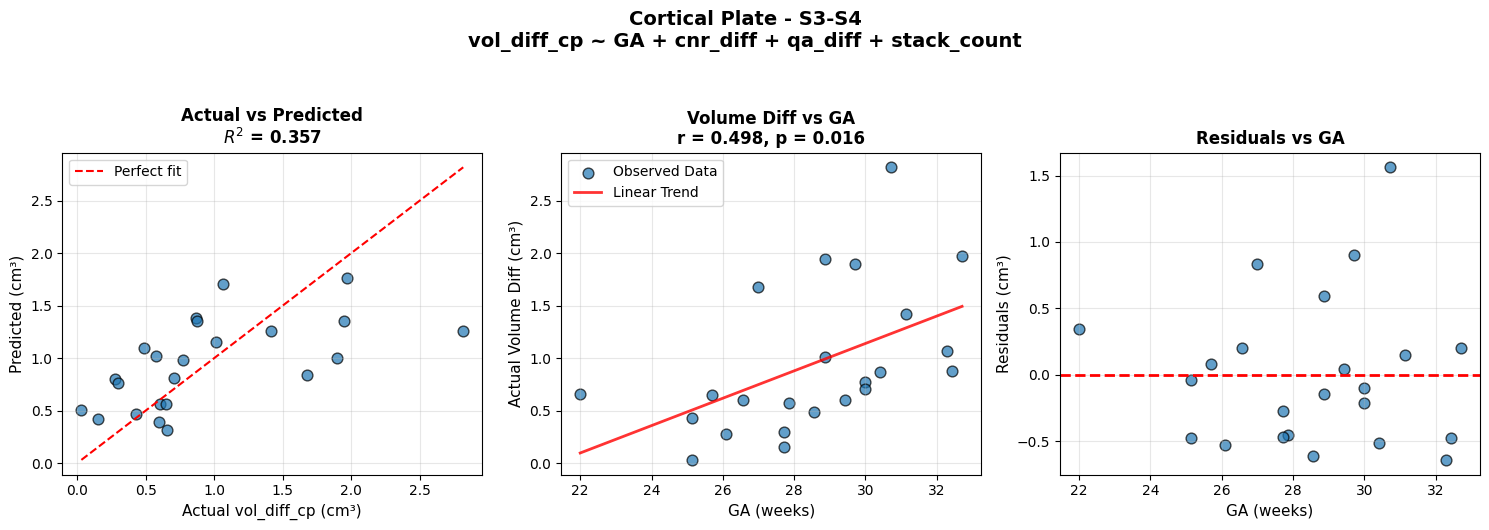

In [48]:
print("=" * 80)
print("CNR-DIFF MODEL: Vol_diff ~ GA + CNR_diff + QA_diff + stack_count")
print("(Uses CNR difference between splits - contrast-based quality metric)")
print("=" * 80)

# Prepare data for CNR models (split_comp_df already contains cnr_diff and cnr_mean)
data_cnr_S1S2 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S1-S2")
data_cnr_S3S4 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S3-S4")

print("\nData prepared:")
print(f"  S1-S2: {len(data_cnr_S1S2)} subjects")
print(f"  S3-S4: {len(data_cnr_S3S4)} subjects")

# Define CNR model predictors
cnr_diff_predictors = ["GA", "cnr_diff", "qa_diff", "stack_count"]
cnr_mean_predictors = ["GA", "cnr_mean", "qa_diff", "stack_count"]

# Run CNR-Diff models using universal function
results_cnr_diff = []
cnr_diff_configs = [
    (data_cnr_S1S2, "vol_diff_sp", "sp", "S1-S2", "Subplate"),
    (data_cnr_S3S4, "vol_diff_sp", "sp", "S3-S4", "Subplate"),
    (data_cnr_S1S2, "vol_diff_cp", "cp", "S1-S2", "Cortical Plate"),
    (data_cnr_S3S4, "vol_diff_cp", "cp", "S3-S4", "Cortical Plate"),
]

for data, outcome_col, tissue, split_pair, tissue_name in cnr_diff_configs:
    result = run_regression_model(
        df=data,
        outcome_col=outcome_col,
        predictors=cnr_diff_predictors,
        model_name="CNR-Diff",
        split_pair=split_pair,
        tissue=tissue,
        print_results=True
    )
    results_cnr_diff.append(result)

# Comparison table for CNR-Diff
compare_models(results_cnr_diff)

# Generate plots for CNR-Diff
print(f"\n{'='*80}")
print("GENERATING CNR-DIFF MODEL VISUALIZATIONS")
print(f"{'='*80}")

for i, (data, outcome_col, tissue, split_pair, tissue_name) in enumerate(cnr_diff_configs):
    if results_cnr_diff[i] is not None:
        fig = plot_regression_results(
            df=data,
            outcome_col=outcome_col,
            model_result=results_cnr_diff[i],
            tissue_name=tissue_name,
            split_pair=split_pair
        )
        plt.show()


# ### CNR-Mean Model Application: Vol_diff ~ GA + CNR_mean + QA_diff + stack_count

\n================================================================================
CNR-MEAN MODEL: Vol_diff ~ GA + CNR_mean + QA_diff + stack_count
(Uses mean CNR across splits - overall contrast quality metric)

Table: Regression of SP Volume Diff (S1-S2)
Variable       Coef      SE       t    p-value
-----------  ------  ------  ------  ---------
Intercept    -1.804   1.458  -1.240      0.232
GA            0.082   0.045   1.820      0.085
cnr_mean      6.338  27.520   0.230      0.820
qa_diff      -0.956   1.397  -0.680      0.503
stack_count   0.010   0.036   0.270      0.793
R-squared            0.176
Adj. R-squared      -0.007
N                       23
F-statistic           0.96

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                 10.57 *
  cnr_mean            4.74
  qa_diff             2.63
  stack_count         6.04 *

Table: Regression of SP Volume Diff (S3-S4)
Variable       Coef      SE       t  p-value
-----------  ----

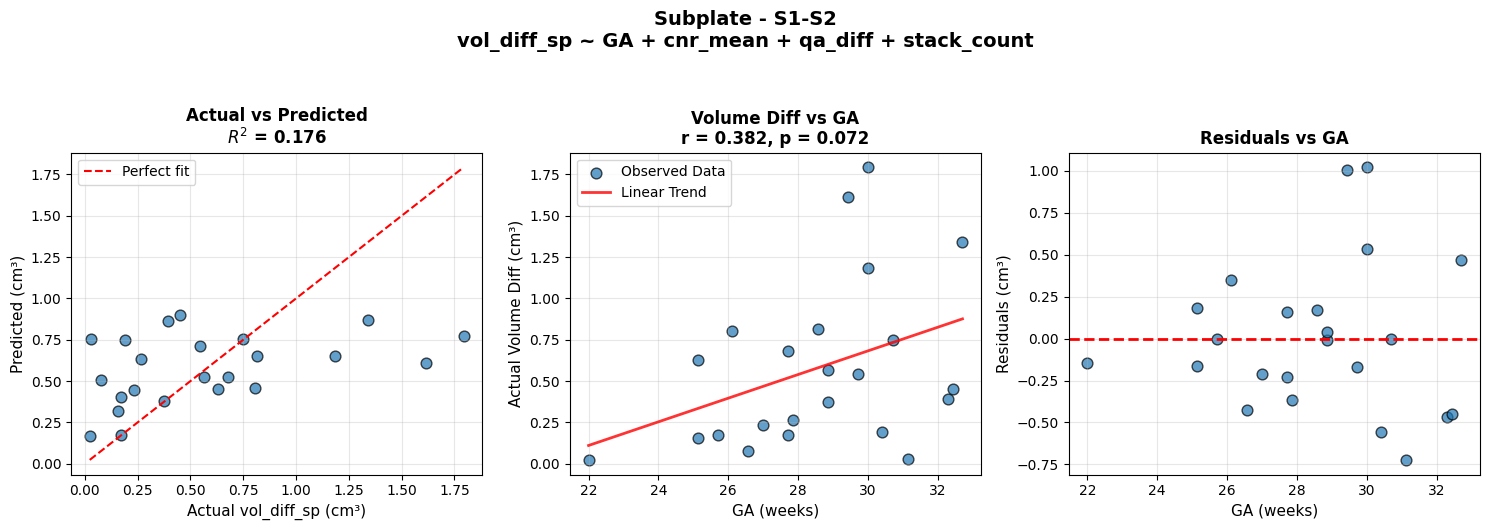

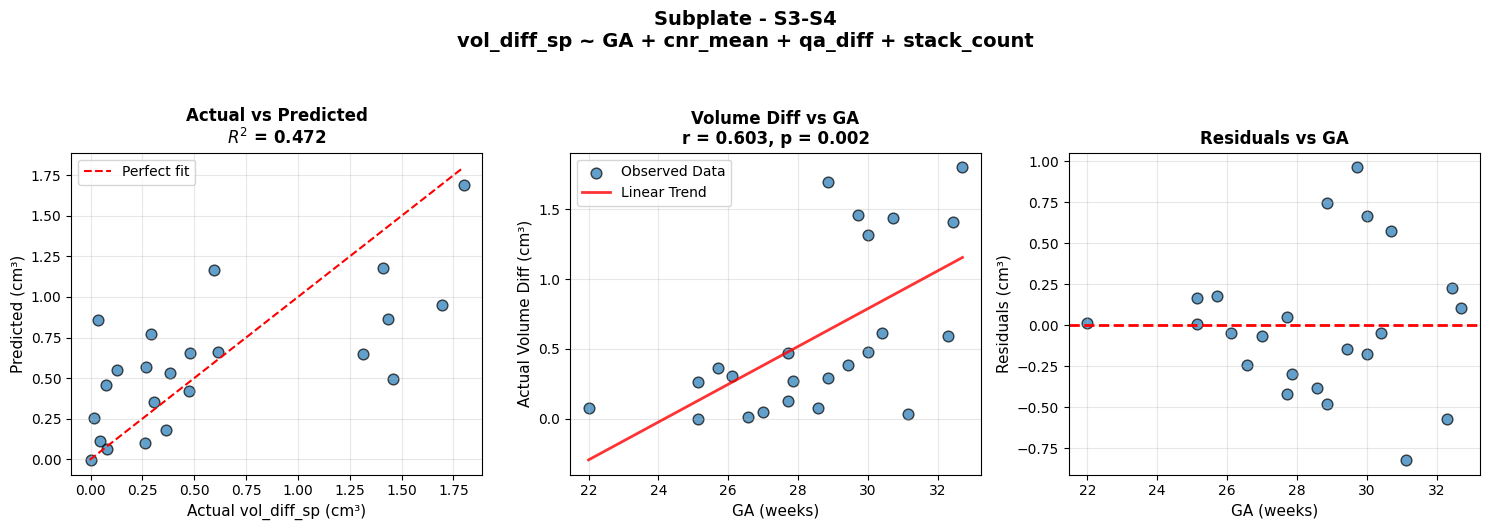

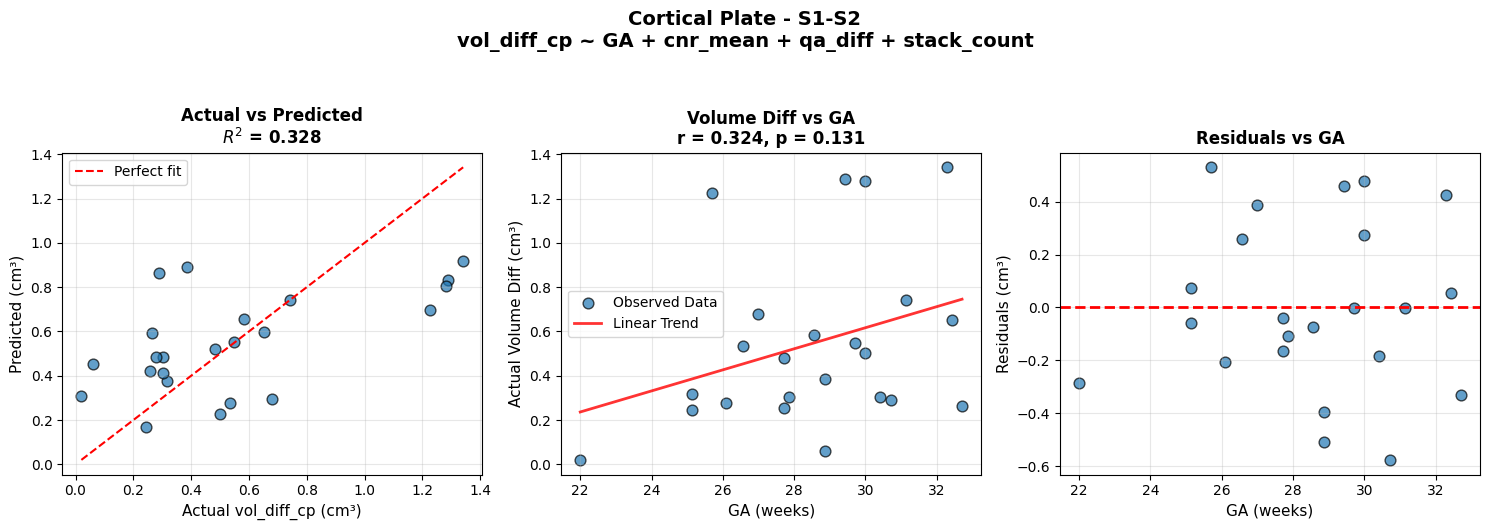

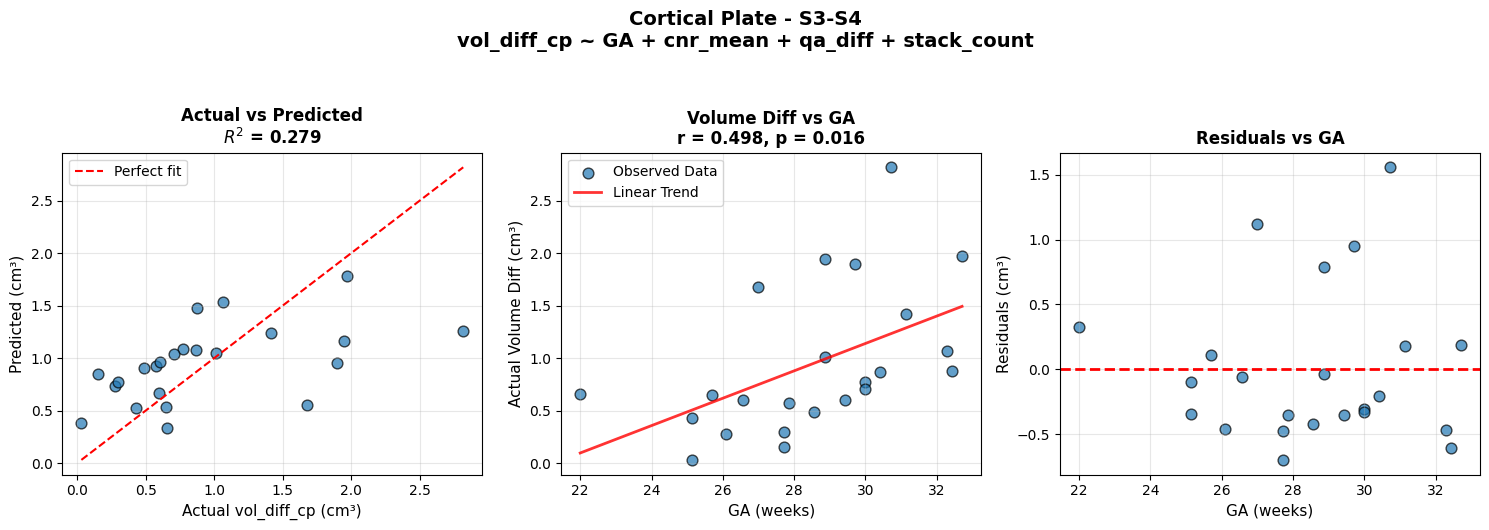

In [49]:


# =============================================================================
# CNR-MEAN MODEL APPLICATION
# =============================================================================

print("\\n" + "=" * 80)
print("CNR-MEAN MODEL: Vol_diff ~ GA + CNR_mean + QA_diff + stack_count")
print("(Uses mean CNR across splits - overall contrast quality metric)")
print("=" * 80)

# Run CNR-Mean models using universal function (using same data as CNR-Diff)
results_cnr_mean = []
cnr_mean_configs = [
    (data_cnr_S1S2, "vol_diff_sp", "sp", "S1-S2", "Subplate"),
    (data_cnr_S3S4, "vol_diff_sp", "sp", "S3-S4", "Subplate"),
    (data_cnr_S1S2, "vol_diff_cp", "cp", "S1-S2", "Cortical Plate"),
    (data_cnr_S3S4, "vol_diff_cp", "cp", "S3-S4", "Cortical Plate"),
]

for data, outcome_col, tissue, split_pair, tissue_name in cnr_mean_configs:
    result = run_regression_model(
        df=data,
        outcome_col=outcome_col,
        predictors=cnr_mean_predictors,
        model_name="CNR-Mean",
        split_pair=split_pair,
        tissue=tissue,
        print_results=True
    )
    results_cnr_mean.append(result)

# Comparison table for CNR-Mean
compare_models(results_cnr_mean)

# Generate plots for CNR-Mean
print(f"\\n{'='*80}")
print("GENERATING CNR-MEAN MODEL VISUALIZATIONS")
print(f"{'='*80}")

for i, (data, outcome_col, tissue, split_pair, tissue_name) in enumerate(cnr_mean_configs):
    if results_cnr_mean[i] is not None:
        fig = plot_regression_results(
            df=data,
            outcome_col=outcome_col,
            model_result=results_cnr_mean[i],
            tissue_name=tissue_name,
            split_pair=split_pair
        )
        plt.show()